# Modul 12 — Pengenalan Deep Learning Dasar (PyTorch)
## Konseptual, mereproduksi dataset Modul 7 (Bank Arta Nusantara)

Notebook ini menjalankan jaringan saraf sederhana Modul 12: forward pass
manual, training loop, kurva loss, perbandingan dengan logistic regression,
dan eksperimen learning rate.

## Data dan Model

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score

np.random.seed(42)
n = 800
pendapatan_juta = np.clip(np.random.normal(14, 6, n), 4, 60)
usia = np.clip(np.random.normal(37, 9, n), 21, 65).round().astype(int)
skor_kredit = np.clip(0.7 * pendapatan_juta + np.random.normal(55, 10, n), 20, 100)
jumlah_tanggungan = np.clip(np.random.poisson(1.8, n), 0, 6)
rasio_cicilan_pendapatan = np.clip(np.random.normal(0.32, 0.12, n), 0.05, 0.9)
jenis_kredit = np.random.choice(["KPR", "UMKM"], size=n, p=[0.55, 0.45])
logit = (-3.2 - 0.05 * (skor_kredit - 60) + 4.5 * (rasio_cicilan_pendapatan - 0.3)
    + 0.18 * jumlah_tanggungan - 0.01 * (usia - 37) + np.where(jenis_kredit == "UMKM", 0.4, 0.0))
gagal_bayar = np.random.binomial(1, 1 / (1 + np.exp(-logit)))

df = pd.DataFrame({"pendapatan_juta": pendapatan_juta.round(2), "usia": usia,
    "skor_kredit": skor_kredit.round(1), "jumlah_tanggungan": jumlah_tanggungan,
    "rasio_cicilan_pendapatan": rasio_cicilan_pendapatan.round(3),
    "jenis_kredit": jenis_kredit, "gagal_bayar": gagal_bayar})

fitur_numerik = ["pendapatan_juta", "usia", "skor_kredit", "jumlah_tanggungan", "rasio_cicilan_pendapatan"]
fitur_kategorikal = ["jenis_kredit"]
X = df[fitur_numerik + fitur_kategorikal]
y = df["gagal_bayar"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

preprocessor = ColumnTransformer([("num", StandardScaler(), fitur_numerik), ("cat", OneHotEncoder(drop="first"), fitur_kategorikal)])
X_train_proc = preprocessor.fit_transform(X_train).astype(np.float32)
X_test_proc = preprocessor.transform(X_test).astype(np.float32)
X_train_t = torch.tensor(X_train_proc)
y_train_t = torch.tensor(y_train.values.astype(np.float32)).reshape(-1, 1)
X_test_t = torch.tensor(X_test_proc)

class JaringanKredit(nn.Module):
    def __init__(self, n_fitur):
        super().__init__()
        self.hidden = nn.Linear(n_fitur, 8)
        self.output = nn.Linear(8, 1)
    def forward(self, x):
        x = torch.relu(self.hidden(x))
        x = torch.sigmoid(self.output(x))
        return x

torch.manual_seed(42)
model = JaringanKredit(n_fitur=X_train_t.shape[1])
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

riwayat_loss = []
for epoch in range(200):
    optimizer.zero_grad()
    pred = model(X_train_t)
    loss = loss_fn(pred, y_train_t)
    loss.backward()
    optimizer.step()
    riwayat_loss.append(loss.item())

with torch.no_grad():
    proba_test = model(X_test_t).numpy().flatten()
print(f"Loss awal: {riwayat_loss[0]:.4f}, Loss akhir: {riwayat_loss[-1]:.4f}")
print(f"ROC-AUC jaringan saraf: {roc_auc_score(y_test, proba_test):.4f}")

Loss awal: 0.6842, Loss akhir: 0.1828
ROC-AUC jaringan saraf: 0.6436


## Visualisasi 1: Kurva Loss Sungguhan (Asset Baru, mengganti M12-02)

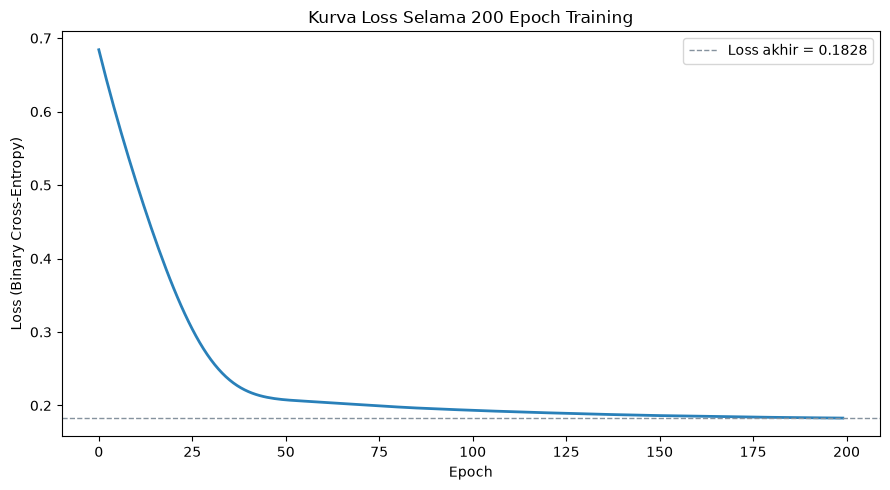

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(riwayat_loss, color="#2980B9", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (Binary Cross-Entropy)")
ax.set_title("Kurva Loss Selama 200 Epoch Training")
ax.axhline(riwayat_loss[-1], color="#85929E", linestyle="--", linewidth=1,
           label=f"Loss akhir = {riwayat_loss[-1]:.4f}")
ax.legend()
plt.tight_layout()
plt.savefig("modul12_kurva_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## Visualisasi 2: Eksperimen Learning Rate (Asset Baru, menjawab Studi Kasus lebih awal)

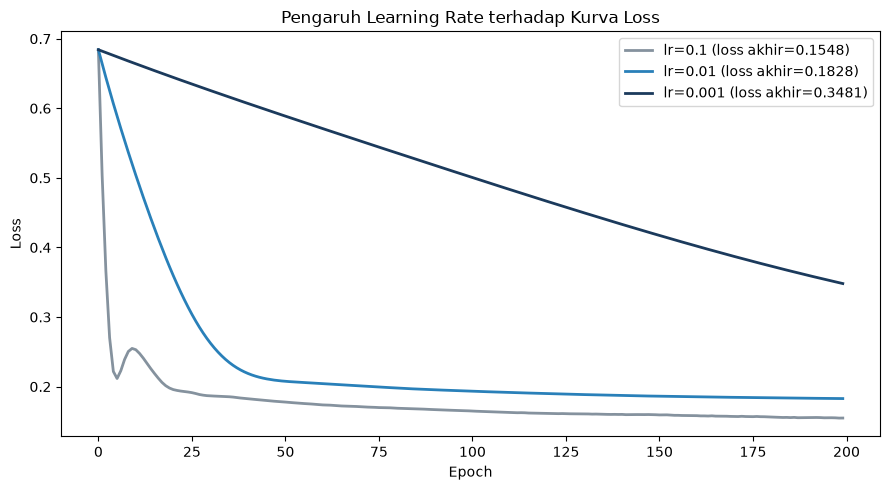

lr=0.1: loss awal=0.6842, loss akhir=0.1548, min=0.1548, max=0.6842
lr=0.01: loss awal=0.6842, loss akhir=0.1828, min=0.1828, max=0.6842
lr=0.001: loss awal=0.6842, loss akhir=0.3481, min=0.3481, max=0.6842


In [3]:
hasil_lr = {}
for lr in [0.1, 0.01, 0.001]:
    torch.manual_seed(42)
    model_lr = JaringanKredit(n_fitur=X_train_t.shape[1])
    opt_lr = torch.optim.Adam(model_lr.parameters(), lr=lr)
    riwayat = []
    for epoch in range(200):
        opt_lr.zero_grad()
        pred = model_lr(X_train_t)
        loss = loss_fn(pred, y_train_t)
        loss.backward()
        opt_lr.step()
        riwayat.append(loss.item())
    hasil_lr[lr] = riwayat

fig, ax = plt.subplots(figsize=(9, 5))
warna = {0.1: "#85929E", 0.01: "#2980B9", 0.001: "#1B3A5C"}
for lr, riwayat in hasil_lr.items():
    ax.plot(riwayat, color=warna[lr], linewidth=2, label=f"lr={lr} (loss akhir={riwayat[-1]:.4f})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Pengaruh Learning Rate terhadap Kurva Loss")
ax.legend()
plt.tight_layout()
plt.savefig("modul12_learning_rate.png", dpi=150, bbox_inches="tight")
plt.show()
for lr, riwayat in hasil_lr.items():
    print(f"lr={lr}: loss awal={riwayat[0]:.4f}, loss akhir={riwayat[-1]:.4f}, min={min(riwayat):.4f}, max={max(riwayat):.4f}")